In [59]:
import global3d_track as g3d
import datetime
import os
import xarray as xr
import pandas as pd
import numpy as np
import pathlib
import matplotlib.pyplot as plt

outdir = pathlib.Path('/work/bb1153/b382635/plots/TRACERMIP/tracking_dev')
datadir = pathlib.Path('/work/bb1153/b382635/plots/TRACERMIP/tracking_dev/data')
os.makedirs(outdir, exist_ok=1)
os.makedirs(datadir, exist_ok=1)

In [54]:
# configuration files

main_config = '/home/b/b382635/s/my_notebooks/Maor/track_master.yaml'

In [22]:
# test loading the data

In [36]:
# cld data
fdir = pathlib.Path('/work/bb1368/b382152/experiments/sea_breeze_houston_toyR2B12/')
qpath = list(fdir.glob('*perturbed_baseline*v1/sea_breeze_houston*cld*'))[0]
wpath = list(fdir.glob('*perturbed_baseline*v1/sea_breeze_houston*dyn*'))[0]
cld = xr.open_dataset(qpath)
w = xr.open_dataset(wpath)

In [26]:
# calc total ice
qi_vars = ['cli','qg','qs','qh']
qi = xr.concat([cld[q] for q in qi_vars], dim='q').sum('q', skipna=True) # kg kg-1

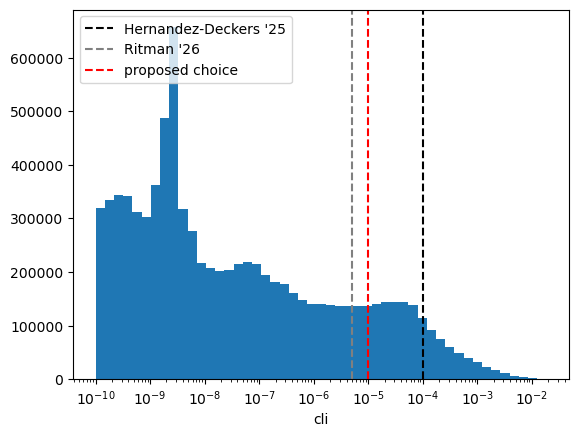

In [48]:
# view cld distribution

# threshold from Daniel Hernandez-Deckers et al., 2025
hd25 = 1e-4 # kg m-3 (same order of magnitude as if in units kg kg-3 as density is close to 1)
# from Ritman et al., 2026
rit26 = .5e-5 # kg kg-1

# proposed choice
sela26 = 1e-5 # kg kg-1

# plot
fig, ax = plt.subplots()
bins = np.logspace(np.log10(1e-10), np.log10(qi.max()), 50)
_ = qi.plot.hist(bins=bins)
ax.axvline(hd25, ls='--', label="Hernandez-Deckers '25", c='k')
ax.axvline(rit26, ls='--', label="Ritman '26", c='grey')
ax.axvline(sela26, ls='--', label='proposed choice', c='r')
ax.set_xscale('log')
ax.legend()

fig.savefig(outdir / 'qi_threshold_choice.jpg')

In [72]:
# preprocess for tracking
# needs: to be ready to enter the func below

sel = qi
seg = qi
tobac_config = '/home/b/b382635/s/my_notebooks/Maor/tobac_params_cond.yaml'
extra_params = dict(savedir=datadir)


module = g3d.methods.tobac_wrapper.Track(sel, seg, tobac_config, overwrite=True, track_params=extra_params)
tobac_methods = {'detect': True, 'segment': True, 'save': False}

In [73]:
module.select_data

Cli (unknown),time,air_pressure,latitude,longitude
Shape,43,21,305,313
Dimension coordinates,,,,
time,x,-,-,-
air_pressure,-,x,-,-
latitude,-,-,x,-
longitude,-,-,-,x


In [75]:
ds, df = module.perform(**tobac_methods)

INFO:root:2026-03-05 19:38:12.808418 Output will save to: /work/bb1153/b382635/plots/TRACERMIP/tracking_dev/data/frozen
INFO:root:Start watershedding 3D


In [76]:
ds

<xarray.Dataset> Size: 345MB
Dimensions:  (time: 43, plev: 21, lat: 305, lon: 313)
Coordinates:
  * time     (time) datetime64[ns] 344B 2022-06-17T03:00:00 ... 2022-06-18
  * plev     (plev) float64 168B 5e+03 1e+04 1.5e+04 ... 9.5e+04 9.75e+04 1e+05
  * lat      (lat) float64 2kB 30.55 30.54 30.54 30.53 ... 28.44 28.43 28.42
  * lon      (lon) float64 3kB -96.35 -96.34 -96.33 ... -93.87 -93.86 -93.85
Data variables:
    feature  (time, plev, lat, lon) int32 345MB ...

In [77]:
df

,frame,idx,vdim,hdim_1,hdim_2,num,threshold_value,feature,time,timestr,air_pressure,latitude,longitude
0,26,5,3.477169,282.477318,158.195448,101,0.00100,1,2022-06-17 16:00:00,2022-06-17 16:00:00,22385.845292,28.572659,-95.084436
1,26,6,4.455504,286.671016,167.976276,296,0.00100,2,2022-06-17 16:00:00,2022-06-17 16:00:00,27277.519988,28.543303,-95.006190
2,27,5,4.840912,129.166227,234.104984,195,0.00010,3,2022-06-17 16:30:00,2022-06-17 16:30:00,29204.560205,29.645836,-94.477160
3,27,6,5.045929,280.836416,131.587059,78,0.00010,4,2022-06-17 16:30:00,2022-06-17 16:30:00,30229.646866,28.584145,-95.297304
4,27,9,4.726516,283.559383,161.663985,220,0.00100,5,2022-06-17 16:30:00,2022-06-17 16:30:00,28632.579526,28.565084,-95.056688
...,...,...,...,...,...,...,...,...,...,...,...,...,...
259,42,4,5.841008,0.329652,195.925112,902,0.00001,260,2022-06-18 00:00:00,2022-06-18 00:00:00,34205.041638,30.547692,-94.782599
260,42,7,4.608310,115.315609,160.803102,5086,0.00010,261,2022-06-18 00:00:00,2022-06-18 00:00:00,28041.550678,29.742791,-95.063575
261,42,8,4.030828,108.045570,288.688587,598,0.00010,262,2022-06-18 00:00:00,2022-06-18 00:00:00,25154.139720,29.793681,-94.040491
262,42,16,4.678429,150.553756,140.535340,175,0.00010,263,2022-06-18 00:00:00,2022-06-18 00:00:00,28392.146700,29.496124,-95.225717
